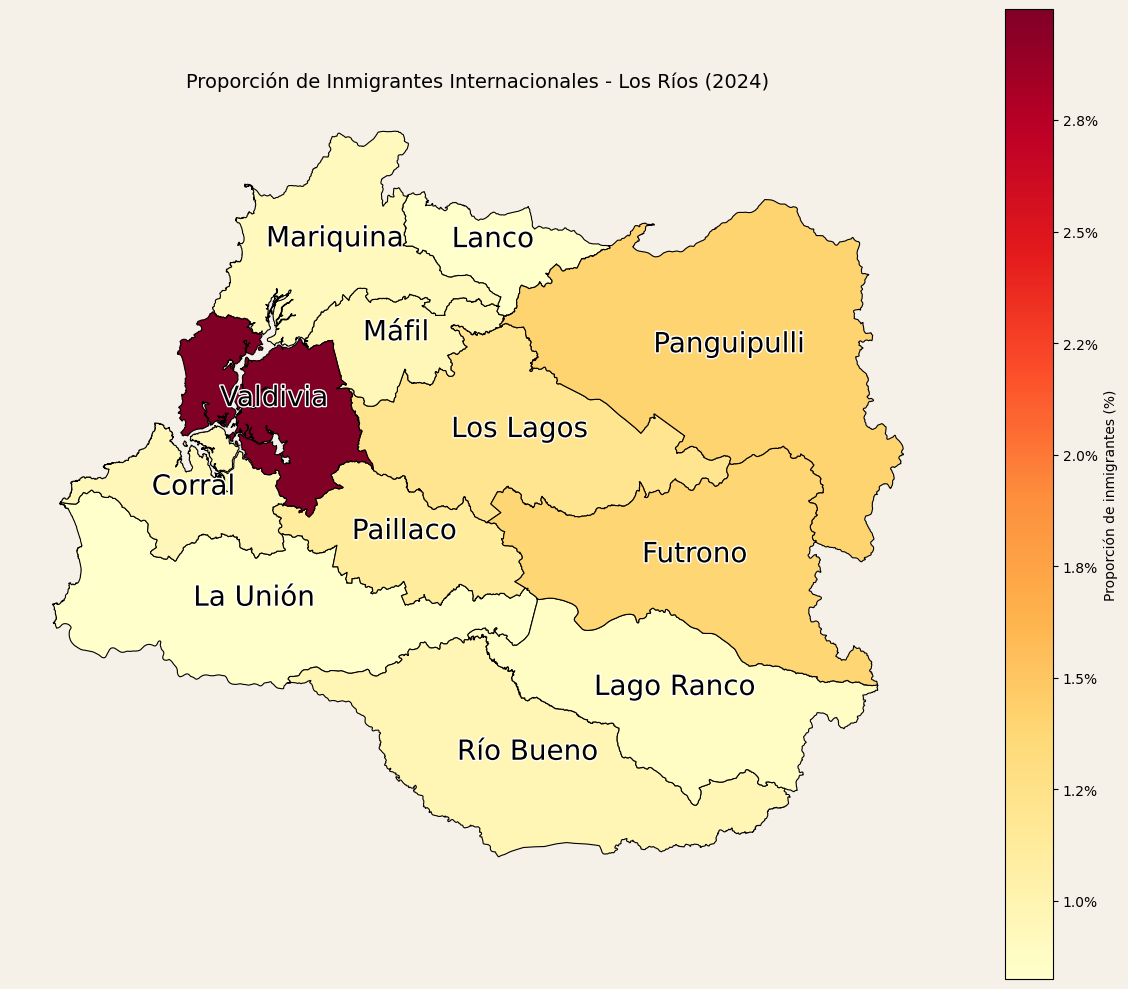

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
from matplotlib import patheffects

# ── Censo 2024 - Inmigrantes ───────────────
df24 = pd.read_excel("D4_Inmigracion-Internacional.xlsx", sheet_name="4", skiprows=3)
df24.columns = df24.columns.str.strip()
colMigrantes24 = df24.columns[7]
dfLosRios24 = df24[df24["Región"] == "Los Ríos"].copy()
dfLosRios24 = dfLosRios24[
    ~dfLosRios24["País o continente de nacimiento"]
    .str.contains("Total nacidos fuera del país", na=False)
]
migrantesComuna24 = dfLosRios24.groupby("Comuna")[colMigrantes24].sum().reset_index()
migrantesComuna24.rename(columns={colMigrantes24: "Migrantes"}, inplace=True)
migrantesComuna24["Comuna"] = migrantesComuna24["Comuna"].str.strip().str.title()

# ── Censo 2024 - Población censada ─────────
df_interna = pd.read_excel("D5_Migracion-interna.xlsx", sheet_name=2, skiprows=3)
poblacion = df_interna[
    df_interna["Región de residencia habitual actual"] == "Los Ríos"
][["Comuna de residencia habitual actual", "Población censada"]].copy()
poblacion.rename(columns={
    "Comuna de residencia habitual actual": "Comuna",
    "Población censada": "Población"
}, inplace=True)
poblacion["Comuna"] = poblacion["Comuna"].str.strip().str.title()

# ── Proporción ─────────────────────────────
datos24 = pd.merge(migrantesComuna24, poblacion, on="Comuna", how="left")
datos24["Proporción (%)"] = (datos24["Migrantes"] / datos24["Población"]) * 100

# ── Shapefile ──────────────────────────────
gdf = gpd.read_file("comunas.shp")
los_rios = gdf[gdf["codregion"] == 14].copy()
los_rios["Comuna"] = los_rios["Comuna"].str.strip().str.title()

mapa24 = los_rios.merge(datos24, on="Comuna", how="left")

# ── Graficar ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
cmap = cm.YlOrRd
norm = Normalize(vmin=mapa24["Proporción (%)"].min(), vmax=mapa24["Proporción (%)"].max())

mapa24.plot(
    column="Proporción (%)",
    ax=ax,
    cmap=cmap,
    norm=norm,
    edgecolor="black",
    linewidth=0.8,
    missing_kwds={"color": "lightgrey", "label": "Sin datos"}
)
# 👇 Fondo beige
fig.patch.set_facecolor("#F5F0E8")
# Etiquetas estilo mapa base 👇
for _, row in mapa24.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(
        row["Comuna"],
        xy=(centroid.x, centroid.y),
        ha="center",
        fontsize=20,
        color="black",
        path_effects=[
            patheffects.withStroke(linewidth=2, foreground="white")
        ]
    )

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Proporción de inmigrantes (%)")
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

ax.set_title("Proporción de Inmigrantes Internacionales - Los Ríos (2024)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()